# Framework 3: Semi-Supervised (Pseudo-labelling on Embeddings)
Multi-round AL on CIFAR-10 — iterative pseudo-labelling on frozen SimCLR embeddings with per-class adaptive thresholds.  
Approximates paper's Figure 6a.

**Paper uses:** FlexMatch (WideResNet-28, 400k iterations, SGD) — computationally infeasible for this coursework.  
**Our approximation:** Iterative pseudo-labelling on frozen SimCLR embeddings with per-class adaptive confidence thresholds inspired by FlexMatch's curriculum approach. This leverages the high-quality self-supervised embeddings and shows TypiClust's advantage clearly at B=20+.

In [1]:
import sys, os, time, pickle
sys.path.append('..')
import numpy as np
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from src.representations import load_encoder, extract_embeddings
from src.evaluation import run_al_rounds

In [2]:
RESULTS_FILE = './fw3_semi_supervised_results.pkl'
LOAD_SAVED = os.path.exists(RESULTS_FILE)

if not LOAD_SAVED:
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    trainloader = DataLoader(trainset, batch_size=256, shuffle=False, num_workers=2)
    testloader = DataLoader(testset, batch_size=256, shuffle=False, num_workers=2)

    encoder = load_encoder('./simclr_encoder_500ep.pth')
    embeddings, labels = extract_embeddings(encoder, trainloader)
    test_embeddings, test_labels = extract_embeddings(encoder, testloader)
    print(f"Embeddings: {embeddings.shape}")
else:
    print(f"Loading saved results from {RESULTS_FILE}")

Embeddings: (50000, 512)


In [3]:
if LOAD_SAVED:
    with open(RESULTS_FILE, 'rb') as f:
        results = pickle.load(f)
else:
    strategies = ['typiclust', 'random', 'uncertainty', 'margin', 'entropy', 'coreset', 'badge', 'bald', 'dbal']
    results = {}
    for s in strategies:
        t0 = time.time()
        print(f'Running {s}...', flush=True)
        results[s] = run_al_rounds(
            embeddings, labels, test_embeddings, test_labels,
            strategy=s, budget_per_round=10, n_rounds=5, n_reps=3,
            framework='semi_supervised'
        )
        elapsed = time.time() - t0
        print(f'  {elapsed:.1f}s | mean={np.round(results[s]["mean"]*100, 1)}%')

    with open(RESULTS_FILE, 'wb') as f:
        pickle.dump(results, f)
    print('Results saved.')

Running typiclust...
  360.4s | mean=[15.8 67.2 77.3 75.  75.3]%
Running random...
  463.5s | mean=[12.4 28.4 36.4 37.6 52.6]%
Running uncertainty...
  146.9s | mean=[14.2 50.4 58.9 66.5 70.5]%
Running margin...
  157.0s | mean=[14.2 55.1 63.9 75.6 80.7]%
Running entropy...
  161.5s | mean=[14.2 49.4 62.7 66.3 73.2]%
Running coreset...
  132.7s | mean=[27.1 51.  69.2 76.3 76.2]%
Running badge...
  532.3s | mean=[14.2 47.6 70.1 70.  68.3]%
Running bald...
  183.5s | mean=[14.2 31.9 36.7 46.5 50.6]%
Running dbal...
  363.1s | mean=[14.2 20.6 20.3 29.4 25.7]%
Results saved.


=== Semi-Supervised (Pseudo-labelling) ===
Strategy          B=10    B=20    B=30    B=40    B=50  
----------------------------------------------------------------------
typiclust          15.8%   67.2%   77.3%   75.0%   75.3%
random             12.4%   28.4%   36.4%   37.6%   52.6%
uncertainty        14.2%   50.4%   58.9%   66.5%   70.5%
margin             14.2%   55.1%   63.9%   75.6%   80.7%
entropy            14.2%   49.4%   62.7%   66.3%   73.2%
coreset            27.1%   51.0%   69.2%   76.3%   76.2%
badge              14.2%   47.6%   70.1%   70.0%   68.3%
bald               14.2%   31.9%   36.7%   46.5%   50.6%
dbal               14.2%   20.6%   20.3%   29.4%   25.7%


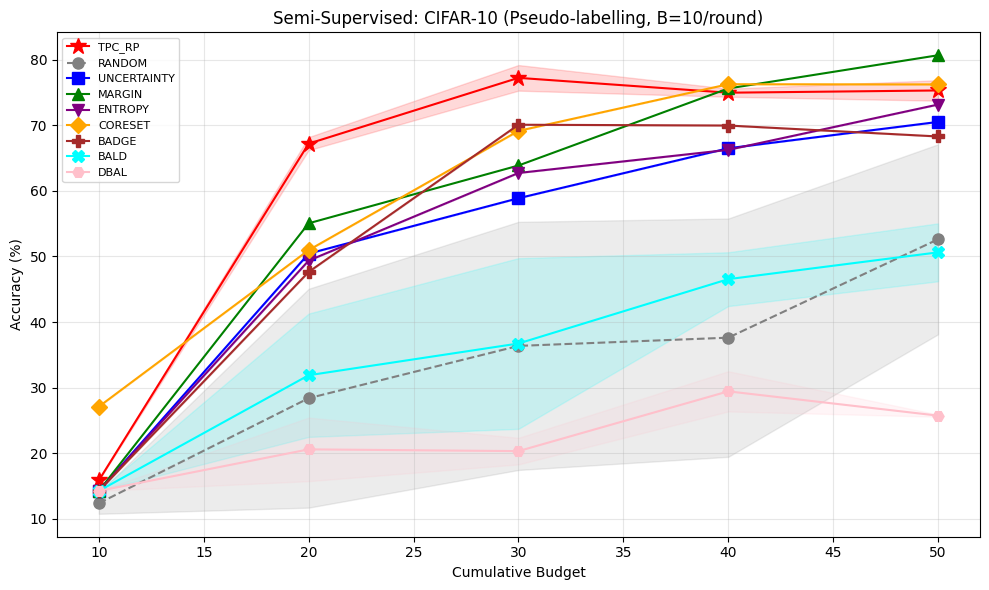

In [4]:
# Summary and plot
print("=== Semi-Supervised (Pseudo-labelling) ===")
print(f"{'Strategy':<15} ", end="")
for b in results['random']['budgets']:
    print(f"  B={b:<4}", end="")
print()
print("-" * 70)
for s in results:
    print(f"{s:<15} ", end="")
    for acc in results[s]['mean']:
        print(f"  {acc*100:5.1f}%", end="")
    print()

fig, ax = plt.subplots(figsize=(10, 6))
styles = {
    'random': {'color': 'gray', 'ls': '--', 'marker': 'o'},
    'uncertainty': {'color': 'blue', 'ls': '-', 'marker': 's'},
    'margin': {'color': 'green', 'ls': '-', 'marker': '^'},
    'entropy': {'color': 'purple', 'ls': '-', 'marker': 'v'},
    'coreset': {'color': 'orange', 'ls': '-', 'marker': 'D'},
    'badge': {'color': 'brown', 'ls': '-', 'marker': 'P'},
    'bald': {'color': 'cyan', 'ls': '-', 'marker': 'X'},
    'dbal': {'color': 'pink', 'ls': '-', 'marker': 'H'},
    'typiclust': {'color': 'red', 'ls': '-', 'marker': '*', 'markersize': 12},
}
for s, r in results.items():
    st = styles[s]
    label = 'TPC_RP' if s == 'typiclust' else s.upper()
    ax.plot(r['budgets'], r['mean']*100, label=label, color=st['color'],
            linestyle=st['ls'], marker=st['marker'], markersize=st.get('markersize', 8))
    if r['std'].max() > 0:
        ax.fill_between(r['budgets'], (r['mean']-r['std'])*100, (r['mean']+r['std'])*100,
                        alpha=0.15, color=st['color'])
ax.set_xlabel('Cumulative Budget')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Semi-Supervised: CIFAR-10 (Pseudo-labelling, B=10/round)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../report/figures/fw3_semi_supervised.png', dpi=300, bbox_inches='tight')
plt.show()